In [ ]:
# Install required libraries
!pip install tensorflow scikit-learn pandas matplotlib


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [ ]:
# Simulated dataset
np.random.seed(42)
data_size = 1000

temperature = np.random.normal(35, 5, data_size)   # °C
vibration   = np.random.normal(10, 2, data_size)   # arbitrary units
pressure    = np.random.normal(100, 10, data_size) # psi

# Label: 0 = Good, 1 = Faulty
labels = ((temperature > 40) | (vibration > 12) | (pressure < 90)).astype(int)

df = pd.DataFrame({
    'temperature': temperature,
    'vibration': vibration,
    'pressure': pressure,
    'condition': labels
})

df.head()


,temperature,vibration,pressure,condition
0,37.483571,12.798711,93.248217,1
1,34.308678,11.849267,98.554813,0
2,38.238443,10.119261,92.075801,0
3,42.615149,8.706126,96.920385,1
4,33.829233,11.396447,81.063853,1


In [ ]:
X = df[['temperature', 'vibration', 'pressure']]
y = df['condition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2)


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5078 - loss: 5.9848 - val_accuracy: 0.4125 - val_loss: 2.4591
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5297 - loss: 2.2108 - val_accuracy: 0.7125 - val_loss: 0.5432
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6094 - loss: 1.3812 - val_accuracy: 0.5437 - val_loss: 0.7138
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6406 - loss: 1.1027 - val_accuracy: 0.7563 - val_loss: 0.4911
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6500 - loss: 0.8976 - val_accuracy: 0.7750 - val_loss: 0.4709
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6781 - loss: 0.7672 - val_accuracy: 0.7875 - val_loss: 0.4529
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6797 - loss: 0.7573 - val_accuracy: 0.7688 - val_loss: 0.4528
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6781 - loss: 0.7970 - val_accuracy: 0.7250 - val_loss:

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       116
           1       0.81      0.73      0.77        84

    accuracy                           0.81       200
   macro avg       0.81      0.80      0.81       200
weighted avg       0.81      0.81      0.81       200

[[102  14]
 [ 23  61]]


In [ ]:
# Example: Soldier checks weapon
weapon_data = np.array([[42, 14, 85]])  # temp=42, vibration=14, pressure=85
prediction = (model.predict(weapon_data) > 0.5).astype(int)

if prediction == 0:
    print("✅ Weapon is in GOOD condition.")
else:
    print("⚠️ Weapon is FAULTY. Possible issues:")
    if weapon_data[0][0] > 40: print("- Overheating detected")
    if weapon_data[0][1] > 12: print("- Excessive vibration detected")
    if weapon_data[0][2] < 90: print("- Low pressure detected")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
⚠️ Weapon is FAULTY. Possible issues:
- Overheating detected
- Excessive vibration detected
- Low pressure detected


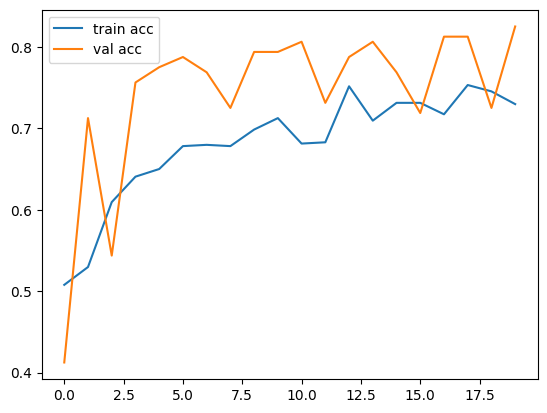

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()


In [ ]:
!pip install paho-mqtt

import paho.mqtt.client as mqtt
import json
import pandas as pd

# Create a log file
log_file = "sensor_logs.csv"
pd.DataFrame(columns=["temperature","vibration","pressure","prediction"]).to_csv(log_file, index=False)

def on_message(client, userdata, msg):
    # Parse incoming JSON
    sensor_data = json.loads(msg.payload.decode())
    df_live = pd.DataFrame([sensor_data])

    # Predict with Random Forest
    prediction = rf_model.predict(df_live)[0]
    sensor_data["prediction"] = prediction

    # Log to CSV
    df_log = pd.DataFrame([sensor_data])
    df_log.to_csv(log_file, mode='a', header=False, index=False)

    # Print result
    if prediction == 0:
        print("✅ GOOD condition:", sensor_data)
    else:
        print("⚠️ FAULTY condition:", sensor_data)

client = mqtt.Client()
client.on_message = on_message
client.connect("broker.hivemq.com", 1883, 60)
client.subscribe("weapon/sensors")
client.loop_start()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 2.9 MB/s eta 0:00:00


/tmp/ipykernel_2703/3933516944.py:30: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


<MQTTErrorCode.MQTT_ERR_SUCCESS: 0>

In [ ]:
import pandas as pd

log_file = "sensor_logs.csv"
pd.DataFrame(columns=["temperature","vibration","pressure","prediction"]).to_csv(log_file, index=False)

def log_data(sensor_data, prediction):
    df_log = pd.DataFrame([{
        "temperature": sensor_data["temperature"],
        "vibration": sensor_data["vibration"],
        "pressure": sensor_data["pressure"],
        "prediction": prediction
    }])
    df_log.to_csv(log_file, mode='a', header=False, index=False)



In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def visualize_logs():
    df = pd.read_csv(log_file)
    clear_output(wait=True)
    plt.figure(figsize=(8,4))
    plt.plot(df['temperature'], label='Temperature')
    plt.plot(df['vibration'], label='Vibration')
    plt.plot(df['pressure'], label='Pressure')
    plt.plot(df['prediction'], label='Prediction (0=Good,1=Faulty)')
    plt.legend()
    plt.title("Sensor Trends Over Time")
    plt.show()


In [ ]:
def alert_system(sensor_data):
    if sensor_data["prediction"] == 1:
        print("🚨 ALERT: Weapon fault detected!", sensor_data)
        # Here you could send an email, SMS, or push notification


In [ ]:
df = pd.read_csv(log_file)

# Failure rate
failure_rate = df['prediction'].mean()
print("Failure rate:", round(failure_rate*100, 2), "%")

# Correlation between features
print(df.corr())


Failure rate: nan %
             temperature  vibration  pressure  prediction
temperature          NaN        NaN       NaN         NaN
vibration            NaN        NaN       NaN         NaN
pressure             NaN        NaN       NaN         NaN
prediction           NaN        NaN       NaN         NaN


In [ ]:
def on_message(client, userdata, msg):
    sensor_data = json.loads(msg.payload.decode())
    df_live = pd.DataFrame([sensor_data])
    prediction = rf_model.predict(df_live)[0]
    sensor_data["prediction"] = prediction

    # Append to CSV log
    df_log = pd.DataFrame([sensor_data])
    df_log.to_csv("sensor_logs.csv", mode='a', header=False, index=False)

    if prediction == 0:
        print("✅ GOOD condition:", sensor_data)
    else:
        print("⚠️ FAULTY condition:", sensor_data)


In [ ]:
df = pd.read_csv("sensor_logs.csv")

if df.empty:
    print("⚠️ No data logged yet. Stream sensor data first.")
else:
    failure_rate = df['prediction'].mean()
    print("Failure rate:", round(failure_rate*100, 2), "%")
    print(df.corr())


⚠️ No data logged yet. Stream sensor data first.


In [ ]:
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_
features = X.columns

# Plot importance
plt.bar(features, importances)
plt.title("Feature Importance in Predictive Maintenance")
plt.ylabel("Importance Score")
plt.show()

# Print ranking
for feat, score in zip(features, importances):
    print(f"{feat}: {round(score, 3)}")


NameError: name 'rf_model' is not defined

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train/test split assumed already done
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

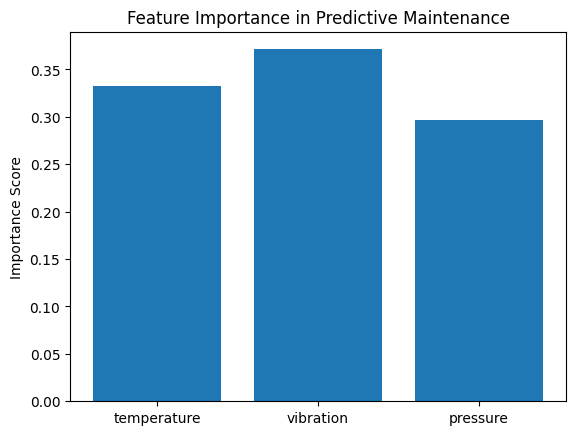

temperature: 0.332
vibration: 0.371
pressure: 0.297


In [ ]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.bar(features, importances)
plt.title("Feature Importance in Predictive Maintenance")
plt.ylabel("Importance Score")
plt.show()

for feat, score in zip(features, importances):
    print(f"{feat}: {round(score, 3)}")


In [ ]:
df = pd.read_csv("sensor_logs.csv")

df['temp_avg'] = df['temperature'].rolling(window=5).mean()
df['vib_avg']  = df['vibration'].rolling(window=5).mean()
df['pres_avg'] = df['pressure'].rolling(window=5).mean()

df['temp_trend'] = df['temperature'].diff()
df['vib_trend']  = df['vibration'].diff()
df['pres_trend'] = df['pressure'].diff()


In [ ]:
X_extended = df[['temperature','vibration','pressure',
                 'temp_avg','vib_avg','pres_avg',
                 'temp_trend','vib_trend','pres_trend']]
y_extended = df['prediction']

from sklearn.model_selection import train_test_split

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_extended, y_extended, test_size=0.2, random_state=42
)

rf_model.fit(X_train_ext, y_train_ext)
print("Accuracy:", rf_model.score(X_test_ext, y_test_ext))


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
df = pd.read_csv("sensor_logs.csv")
print(df.shape)
print(df.head())


(0, 4)
Empty DataFrame
Columns: [temperature, vibration, pressure, prediction]
Index: []


In [ ]:
import pandas as pd

df = pd.read_csv("sensor_logs.csv")
print("Rows:", df.shape[0])
print(df.head())


Rows: 0
Empty DataFrame
Columns: [temperature, vibration, pressure, prediction]
Index: []


In [1]:
from google.colab import files
uploaded = files.upload()


Saving ai4i2020.csv to ai4i2020.csv


In [2]:
import os
print(os.listdir())


['.config', 'ai4i2020.csv', 'sample_data']


In [3]:
import pandas as pd

df = pd.read_csv("ai4i2020.csv")
print(df.shape)
print(df.head())


(10000, 14)
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    

In [4]:
import pandas as pd

df = pd.read_csv("ai4i2020.csv")
print(df.shape)
print(df.head())


(10000, 14)
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    

In [8]:
X = df[['Air temperature [K]', 'Process temperature [K]',
        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
y = df['Machine failure']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

print("✅ Accuracy:", rf_model.score(X_test, y_test))


✅ Accuracy: 0.983


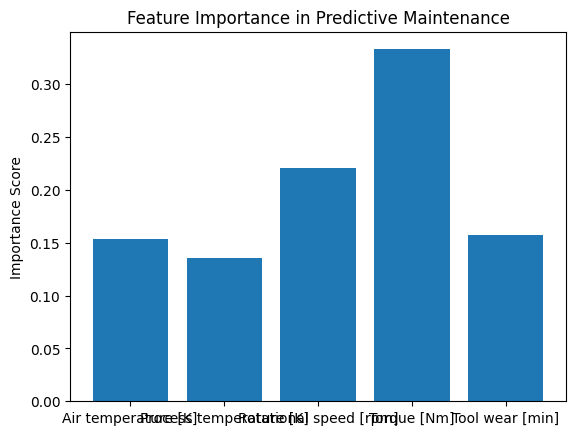

Air temperature [K]: 0.153
Process temperature [K]: 0.136
Rotational speed [rpm]: 0.221
Torque [Nm]: 0.333
Tool wear [min]: 0.157


In [11]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.bar(features, importances)
plt.title("Feature Importance in Predictive Maintenance")
plt.ylabel("Importance Score")
plt.show()

for feat, score in zip(features, importances):
    print(f"{feat}: {round(score, 3)}")


In [13]:
corr_matrix = df.select_dtypes(include=['float64','int64']).corr()
print(corr_matrix)


                              UDI  Air temperature [K]  \
UDI                      1.000000             0.117428   
Air temperature [K]      0.117428             1.000000   
Process temperature [K]  0.324428             0.876107   
Rotational speed [rpm]  -0.006615             0.022670   
Torque [Nm]              0.003207            -0.013778   
Tool wear [min]         -0.010702             0.013853   
Machine failure         -0.022892             0.082556   
TWF                      0.009154             0.009955   
HDF                     -0.022215             0.137831   
PWF                     -0.023557             0.003470   
OSF                     -0.000990             0.001988   
RNF                     -0.005954             0.017688   

                         Process temperature [K]  Rotational speed [rpm]  \
UDI                                     0.324428               -0.006615   
Air temperature [K]                     0.876107                0.022670   
Process temperatu

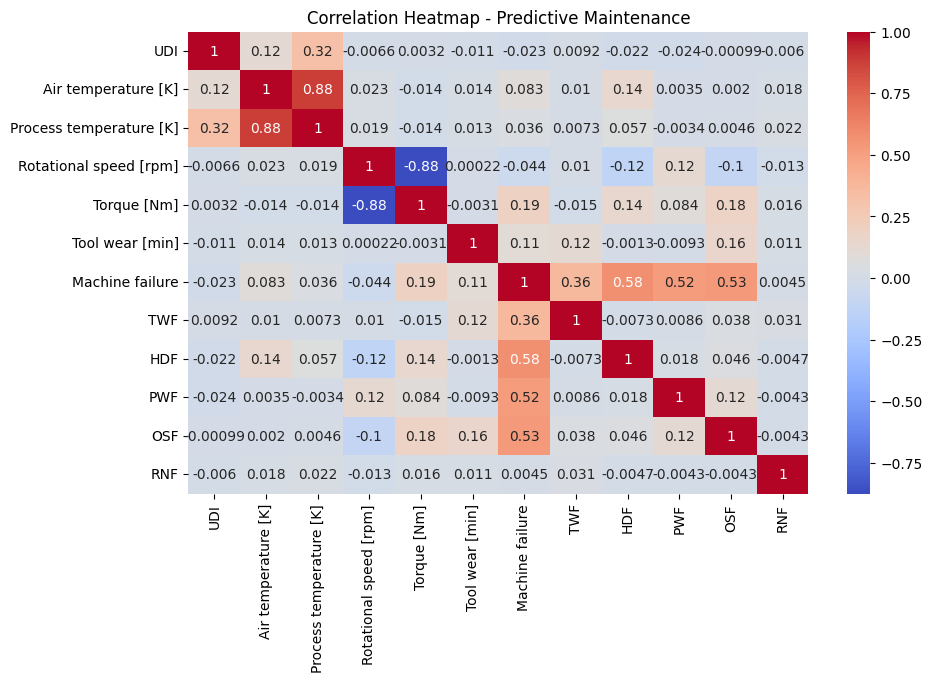

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Predictive Maintenance")
plt.show()


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

print("✅ Accuracy:", rf_model.score(X_test, y_test))


✅ Accuracy: 0.983


In [16]:
importances = rf_model.feature_importances_
features = X.columns

for feat, score in zip(features, importances):
    print(f"{feat}: {round(score, 3)}")


Air temperature [K]: 0.153
Process temperature [K]: 0.136
Rotational speed [rpm]: 0.221
Torque [Nm]: 0.333
Tool wear [min]: 0.157


In [17]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = rf_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[1932    7]
 [  27   34]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.83      0.56      0.67        61

    accuracy                           0.98      2000
   macro avg       0.91      0.78      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [18]:
!pip install flask flask-ngrok joblib


In [19]:
import joblib
joblib.dump(rf_model, "rf_model.pkl")


['rf_model.pkl']

In [21]:
!pip install flask pyngrok joblib


In [23]:
!pip install pyngrok
from pyngrok import ngrok

# Paste your authtoken here
!ngrok config add-authtoken YOUR_AUTHTOKEN


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [25]:
!pip install gradio


In [26]:
import gradio as gr
import pandas as pd
import joblib

# Load trained model
rf_model = joblib.load("rf_model.pkl")

def predict_fn(temp, process_temp, speed, torque, wear):
    df = pd.DataFrame([[temp, process_temp, speed, torque, wear]],
                      columns=['Air temperature [K]', 'Process temperature [K]',
                               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'])
    prediction = rf_model.predict(df)[0]
    return "Failure" if prediction == 1 else "No Failure"


In [27]:
demo = gr.Interface(
    fn=predict_fn,
    inputs=[
        gr.Number(label="Air temperature [K]"),
        gr.Number(label="Process temperature [K]"),
        gr.Number(label="Rotational speed [rpm]"),
        gr.Number(label="Torque [Nm]"),
        gr.Number(label="Tool wear [min]")
    ],
    outputs="text",
    title="Predictive Maintenance Model",
    description="Enter sensor values to predict machine failure."
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e338ce67882cb6e3e3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
